In [2]:
import os

In [3]:
! pip install langchain langchain-groq langchain-huggingface  langchain-community langgraph python-dotenv faiss-cpu pypdf langchain-core langchain-classic 

  Using cached langchain_groq-1.1.2-py3-none-any.whl.metadata (2.4 kB)
  Using cached langchain_community-0.4.1-py3-none-any.whl.metadata (3.0 kB)
  Using cached faiss_cpu-1.13.2-cp313-cp313-win_amd64.whl.metadata (7.6 kB)
  Using cached xxhash-3.6.0-cp313-cp313-win_amd64.whl.metadata (13 kB)
  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
  Using cached ormsgpack-1.12.2-cp313-cp313-win_amd64.whl.metadata (3.3 kB)
  Using cached orjson-3.11.7-cp313-cp313-win_amd64.whl.metadata (43 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached zstandard-0.25.0-cp313-cp313-win_amd64.whl.metadata (3.3 kB)
  Using cached groq-0.37.1-py3-none-any.whl.metadata (16 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached aiohttp-3.13.3-cp313-cp313-win_amd64.whl.metadata (8.4 kB)


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\rahul\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [7]:
from langchain_core.prompts import PromptTemplate
from langgraph.graph.state import StateGraph,START,END
from langchain_groq import ChatGroq
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpointEmbeddings,HuggingFaceEndpoint
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from dotenv import load_dotenv
from typing import TypedDict,Annotated
from langgraph.graph.message import BaseMessage,add_messages
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage
load_dotenv()

True

In [87]:
hf_token=os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")
groq_api_key=os.getenv("GROQ_API_KEY")


In [36]:
Chatmodel=ChatGroq(model="llama-3.1-8b-instant",api_key=groq_api_key,temperature=0.7)
llm_emedding=HuggingFaceEndpointEmbeddings(
    repo_id='BAAI/bge-m3',
    task='feature-extraction',
    huggingfacehub_api_token=hf_token
)


In [35]:
result=Chatmodel.invoke("what is meant by rudra  ")
print(result.content)

In Hindu mythology and philosophy, Rudra is a complex deity with multiple meanings and interpretations. Here are some of the key aspects associated with Rudra:

1. **God of the Storms**: Rudra is often depicted as the god of storms, thunder, and the wind. He is associated with the powerful and destructive forces of nature.
2. **Shiva**: Rudra is also considered one of the many names for the Hindu god Shiva, who is the destroyer of the universe and the transformer of all things. Shiva is often depicted as a benevolent protector and destroyer, and Rudra represents his fierce and destructive aspect.
3. **Fierce and Terrible**: The name Rudra is derived from the Sanskrit word "rud," which means "to cry out" or "to howl." This refers to the fierce and terrifying sound of thunder, which is associated with Rudra.
4. **Lord of the Wilderness**: Rudra is sometimes depicted as a lord of the wilderness, the forests, and the mountains. He is associated with the untamed and the wild, and is said to

In [44]:
! pip install pypdf


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\rahul\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [47]:
loader=PyPDFLoader('css assignmet rk.pdf')
docs=loader.load()


In [46]:
! uv pip install pypdf

Resolved 1 package in 58ms
Prepared 1 package in 49ms
Installed 1 package in 14ms
 + pypdf==6.9.2


In [48]:
len(docs)

21

In [49]:
splitter=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)
chunks=splitter.split_documents(docs)

In [50]:
len(chunks)

39

In [53]:
vector_store=FAISS.from_documents(chunks,llm_emedding)

In [52]:
! uv pip install faiss-cpu

Resolved 3 packages in 79ms
 Downloaded faiss-cpu
Prepared 1 package in 2.20s
Installed 1 package in 13ms
 + faiss-cpu==1.13.2


In [54]:
vector_store

In [55]:
retriver=vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [58]:
@tool
def rag_tool(query):
    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result=retriver.invoke(query)

    content=[doc.page_content for doc in result]
    metadata=[doc.metadata for doc in result]

    return {
        'query':query,
        'content':content,
        'metadata':metadata
    }

In [68]:
tools=[rag_tool]
llm_with_tool=Chatmodel.bind_tools(tools)

In [69]:
class Chatstate(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [70]:
def chat_node(state:Chatstate):

    messages=state['messages']

    response=llm_with_tool.invoke(messages)

    return {
        'messages':[response]
    }

In [74]:
graph=StateGraph(Chatstate)

In [75]:

tool_node=ToolNode(tools)

In [76]:
graph.add_node('chat_node',chat_node)
graph.add_node('tools',tool_node)

graph.add_edge(START,'chat_node')
graph.add_conditional_edges('chat_node',tools_condition)
graph.add_edge('tools','chat_node')

chatbot=graph.compile()

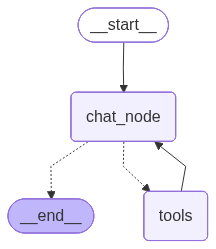

In [77]:
chatbot

In [85]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, Which Cipher Provides Better Diffusion"
                )
            )
        ]
    }
)

In [86]:
print(result['messages'][-1].content)

The Playfair cipher provides the best diffusion among the three classical ciphers. By operating on digraphs, employing a keyword-derived 5×5 matrix, and mixing row, column, and rectangle substitutions, it produces ciphertext that is significantly harder to attack through statistical analysis than either the Caesar or Vigenere ciphers.
